In [113]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pip
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree



In [114]:
dataset = pd.read_csv(r'C:\Users\User\Downloads\Bank Customer Churn Prediction.csv')

Analise Exploratória

In [115]:
dataset.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [116]:
dataset.shape

(10000, 12)

In [117]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 1.0 MB


In [118]:
# Distribuição do churn
contagem = dataset['churn'].value_counts()
porcentagem = dataset['churn'].value_counts(normalize=True) * 100

print('Clientes que ficaram :', contagem[0], f'— {porcentagem[0]:.1f}%')
print('Clientes que saíram :', contagem[1], f'— {porcentagem[1]:.1f}%')

Clientes que ficaram : 7963 — 79.6%
Clientes que saíram : 2037 — 20.4%


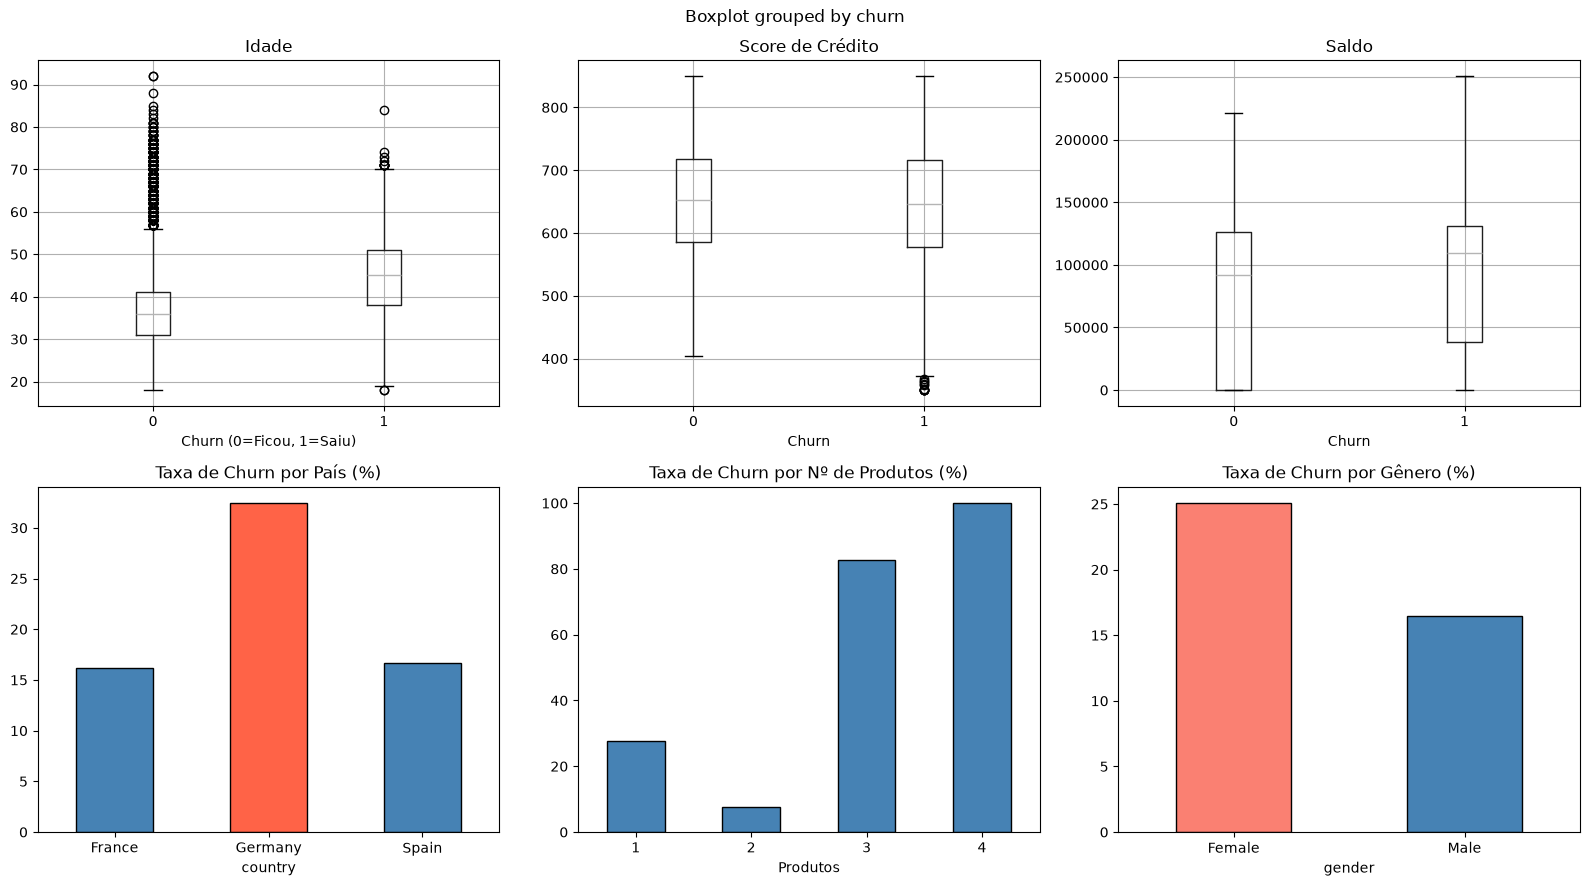

In [119]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Relação das variáveis com Churn', fontsize=14, fontweight='bold')

# Idade
dataset.boxplot(column='age', by='churn', ax=axes[0, 0])
axes[0, 0].set_title('Idade')
axes[0, 0].set_xlabel('Churn (0=Ficou, 1=Saiu)')

# Score de crédito
dataset.boxplot(column='credit_score', by='churn', ax=axes[0, 1])
axes[0, 1].set_title('Score de Crédito')
axes[0, 1].set_xlabel('Churn')

# Saldo
dataset.boxplot(column='balance', by='churn', ax=axes[0, 2])
axes[0, 2].set_title('Saldo')
axes[0, 2].set_xlabel('Churn')

# Churn por país
churn_pais = dataset.groupby('country')['churn'].mean() * 100
churn_pais.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'tomato', 'steelblue'], edgecolor='black')
axes[1, 0].set_title('Taxa de Churn por País (%)')
axes[1, 0].tick_params(axis='x', rotation=0)

# Churn por número de produtos
churn_prod = dataset.groupby('products_number')['churn'].mean() * 100
churn_prod.plot(kind='bar', ax=axes[1, 1], color='steelblue', edgecolor='black')
axes[1, 1].set_title('Taxa de Churn por Nº de Produtos (%)')
axes[1, 1].set_xlabel('Produtos')
axes[1, 1].tick_params(axis='x', rotation=0)

# Churn por gênero
churn_gen = dataset.groupby('gender')['churn'].mean() * 100
churn_gen.plot(kind='bar', ax=axes[1, 2], color=['salmon', 'steelblue'], edgecolor='black')
axes[1, 2].set_title('Taxa de Churn por Gênero (%)')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()

Conventer texto pra número

In [120]:

df = dataset.drop(columns=['customer_id'])

# Converter texto para número
encoder = LabelEncoder()
dataset['country'] = encoder.fit_transform(dataset['country'])  # France=0, Germany=1, Spain=2
dataset['gender']  = encoder.fit_transform(dataset['gender'])   # Female=0, Male=1

# Confirmar
print('country =', dataset['country'].unique())
print('gender =', dataset['gender'].unique())

country = [0 2 1]
gender = [0 1]


Dividindo variaveis de teste

In [121]:
X = dataset.drop(columns=['churn'])  
y = dataset['churn']                 

print('Features (X):', list(X.columns))
print('Shape de X:', X.shape)
print('Shape de y:', y.shape)

Features (X): ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Shape de X: (10000, 11)
Shape de y: (10000,)


In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,    # 30% para teste, 70% para treino
    random_state=0,   # garante sempre o mesmo sorteio
    stratify=y        # mantém proporção de churn nos dois grupos
)

print(f'Treino : {X_train.shape[0]} clientes')
print(f'Teste  : {X_test.shape[0]} clientes')
print()
print(f'% de churn no treino : {y_train.mean():.3f}')
print(f'% de churn no teste  : {y_test.mean():.3f}')

Treino : 7000 clientes
Teste  : 3000 clientes

% de churn no treino : 0.204
% de churn no teste  : 0.204


Criação do modelo

In [123]:
arvore = DecisionTreeClassifier(
    max_depth=5,
    random_state=0,
    class_weight='balanced'
)

arvore.fit(X_train, y_train)

print(f'Profundidade final : {arvore.get_depth()}')
print(f'Número de folhas   : {arvore.get_n_leaves()}')

Profundidade final : 5
Número de folhas   : 31


In [124]:
y_pred = arvore.predict(X_test)              
y_prob = arvore.predict_proba(X_test)[:, 1] 

print('Primeiras 50 previsões:', y_pred[:50])
print('Primeiros 50 reais :', y_test.values[:50])

Primeiras 50 previsões: [0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 1 0 0 0 1 0 1 0
 0 0 0 1 0 1 0 0 0 0 1 0 0]
Primeiros 50 reais : [0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 0 0 0 1 0 0 0 0 0 0 0 0 0]


Avaliação do modelo

In [125]:
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred)
recall   = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_prob)

#print('=== Métricas — Árvore de Decisão ===')
print(f'Acurácia  : {acuracia:.4f}')
print(f'Precisão : {precisao:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(f'ROC-AUC   : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Ficou (0)', 'Cancelou (1)']))

Acurácia  : 0.7700
Precisão : 0.4562
Recall    : 0.6727
F1-Score  : 0.5437
ROC-AUC   : 0.8212

              precision    recall  f1-score   support

   Ficou (0)       0.90      0.79      0.85      2389
Cancelou (1)       0.46      0.67      0.54       611

    accuracy                           0.77      3000
   macro avg       0.68      0.73      0.69      3000
weighted avg       0.81      0.77      0.78      3000



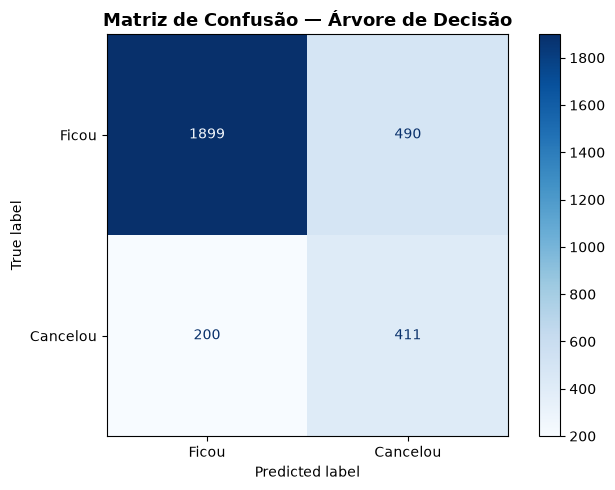

In [126]:
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Ficou', 'Cancelou'],
    cmap='Blues',
    ax=ax
)

ax.set_title('Matriz de Confusão — Árvore de Decisão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

Variaveis importantes

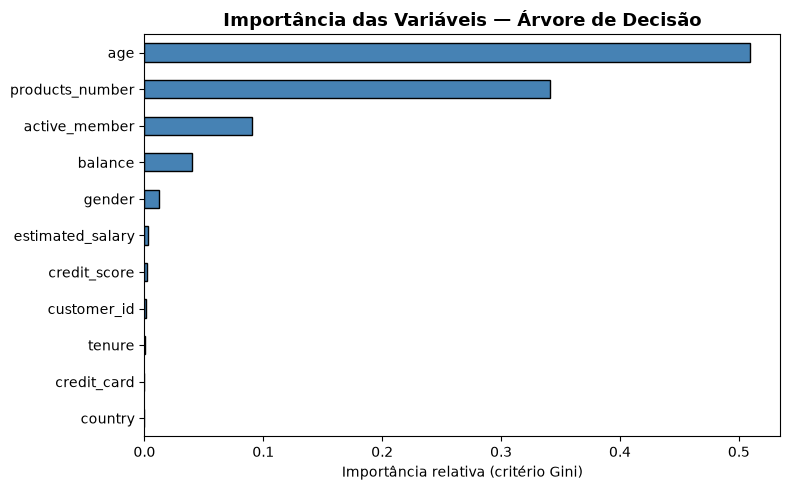

In [127]:
importancias = pd.Series(
    arvore.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Importância das Variáveis — Árvore de Decisão', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância relativa (critério Gini)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()



In [128]:
print('     RESUMO FINAL — ÁRVORE DE DECISÃO\n')
print(f'  Dataset         : Bank Customer Churn (10.000)')
print(f'  Divisão         : 70% treino / 30% teste')
print(f'  max_depth       : 5')
print(f'  class_weight    : balanced')
print(f'  Profundidade    : {arvore.get_depth()}')
print(f'  Nº de folhas    : {arvore.get_n_leaves()}')
#print('\n')
print(f'  Acurácia        : {acuracia:.4f}  ({acuracia*100:.1f}%)')
print(f'  Precision       : {precisao:.4f}  ({precisao*100:.1f}%)')
print(f'  Recall          : {recall:.4f}  ({recall*100:.1f}%)')
print(f'  F1-Score        : {f1:.4f}  ({f1*100:.1f}%)')
print(f'  ROC-AUC         : {auc:.4f}  ({auc*100:.1f}%)')
#print('\n')
print()

top3 = pd.Series(arvore.feature_importances_, index=X.columns)\
         .sort_values(ascending=False).head(3)

print('Top 3 variáveis mais importantes:')
for i, (feat, imp) in enumerate(top3.items(), 1):
    print(f'  {i}. {feat}: {imp*100:.1f}%')

     RESUMO FINAL — ÁRVORE DE DECISÃO

  Dataset         : Bank Customer Churn (10.000)
  Divisão         : 70% treino / 30% teste
  max_depth       : 5
  class_weight    : balanced
  Profundidade    : 5
  Nº de folhas    : 31
  Acurácia        : 0.7700  (77.0%)
  Precision       : 0.4562  (45.6%)
  Recall          : 0.6727  (67.3%)
  F1-Score        : 0.5437  (54.4%)
  ROC-AUC         : 0.8212  (82.1%)

Top 3 variáveis mais importantes:
  1. age: 50.9%
  2. products_number: 34.1%
  3. active_member: 9.0%
